In [1]:
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.feature import hog,local_binary_pattern
import glob
import numpy as np
from sklearn import svm
from skimage import feature
from sklearn.metrics import classification_report
from skimage.color import rgb2gray
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [2]:
# import training data
live_train = glob.glob('data/Training Biometrika Live/live/*.png') #positive
spoof_train = glob.glob('data/Training Biometrika Spoof/Training Biometrika Spoof/spoof/*.png') # negative

# import testing data
live_test = glob.glob('data/Testing Biometrika Live/live/*.png')  # positive
spoof_test = glob.glob('data/Testing Biometrika Spoof/Testing Biometrika Spoof/spoof/*.png') # negative

In [3]:
# initialize empty lists to append data
live_train_images = []
spoof_train_images = []
live_test_images = []
spoof_test_images = []

# read images from given path and append to the variavles
for path in live_train: live_train_images.append(imread(path))
for path in spoof_train: spoof_train_images.append(imread(path))
for path in live_test: live_test_images.append(imread(path))
for path in spoof_test: spoof_test_images.append(imread(path))

In [4]:
# convert images to np arrays
live_train_images, spoof_train_images = np.asarray(live_train_images), np.asarray(spoof_train_images)
live_test_images, spoof_test_images = np.asarray(live_test_images), np.asarray(spoof_test_images)

In [5]:
# Empty List
live_train_features, spoof_train_features = [], []
live_test_features, spoof_test_features = [], []
# LBP Parameters
METHOD = 'uniform'
R = 3
P = 8 * R

# HOG Parameters
orientation = 9
pixel_per_cell = (8,8)
cells_per_block = (2,2)

# Combining Feature
def combined_feat(img):
      img_gray = rgb2gray(img)
      lbp_feat = local_binary_pattern(img_gray, P, R, METHOD).flatten()
      hog_feat = hog(img_gray, 
                   orientations = orientation, 
                   pixels_per_cell = pixel_per_cell, 
                   cells_per_block = cells_per_block, 
                   block_norm = 'L2-Hys', 
                   feature_vector = True)
      
      return np.hstack([lbp_feat, hog_feat])
      
# Process Training Data
for img in live_train_images:
    live_train_features.append(combined_feat(img))

for img in spoof_train_images:
    spoof_train_features.append(combined_feat(img))

# Process Testing Data
for img in live_test_images:
    live_test_features.append(combined_feat(img))

for img in spoof_test_images:
    spoof_test_features.append(combined_feat(img))

print(f"Live Train:{len(live_train_features)}, Spoof Train:{len(spoof_train_features)}")
print(f"Live Test:{len(live_test_features)}, Spoof Test:{len(spoof_test_features)}")

/usr/local/python/3.12.1/lib/python3.12/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Live Train:200, Spoof Train:207
Live Test:200, Spoof Test:200


In [6]:
# define labels 1 for live and 0 for spoof
# i.e. create a list of 200 1's and 200 0's 
labels_train = [[1]]*len(live_train_features) + [[0]]*len(spoof_train_features)

# merge both positive and negative training data
x_train = live_train_features + spoof_train_features

# assign labels for all test data, 1 for positive, 0 for negative
labels_test = [[1]]*len(live_test_features) + [[0]]*len(spoof_test_features)

# merge both positive and negative training data
x_test = live_test_features + spoof_test_features


In [7]:
print(f"live_train: {len(x_train)}, Spoof_train: {len(x_test)}")

live_train: 407, Spoof_train: 400


In [8]:
y_train = labels_train
y_test = labels_test

In [9]:
len(y_train)

407

In [10]:
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)
print(f"Training Set: {x_train.shape[0]} images (Features: {x_train.shape[1]})")
print(f"Testing Set:  {x_test.shape[0]} images")

Training Set: 407 images (Features: 177624)
Testing Set:  400 images


In [11]:
svm_model = svm.SVC(kernel='linear', C= 1.0)
svm_model.fit(x_train, y_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [12]:
y_pred = svm_model.predict(x_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Final Accuracy: {accuracy * 100:.2f}%")


 Final Accuracy: 95.00%


In [14]:
print(classification_report(y_test, y_pred, target_names=['Spoof', 'Live']))

              precision    recall  f1-score   support

       Spoof       0.92      0.98      0.95       200
        Live       0.98      0.92      0.95       200

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



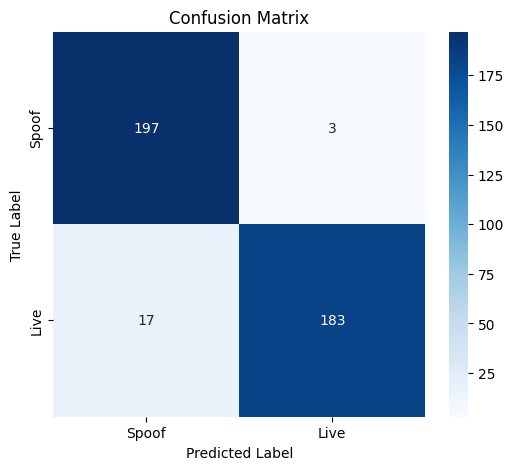

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Spoof', 'Live'], 
            yticklabels=['Spoof', 'Live'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()